In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [40]:
df = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [16]:
df.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [18]:
df.shape


(12, 2)

In [19]:
(df.columns.tolist())

['age', 'Age in years']

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           12 non-null     object
 1   Age in years  12 non-null     object
dtypes: object(2)
memory usage: 324.0+ bytes


In [21]:
df.describe()

,age,Age in years
count,12,12
unique,12,12
top,Gender,"Gender ; Male - 1, Female -0"
freq,1,1


In [22]:
df.isnull().sum()

,0
age,0
Age in years,0


In [32]:
('Duplicate rows:', df.duplicated().sum())

('Duplicate rows:', np.int64(0))

<Axes: >

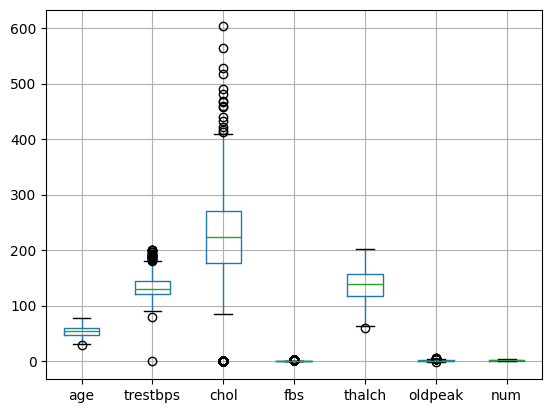

In [41]:
df.boxplot()

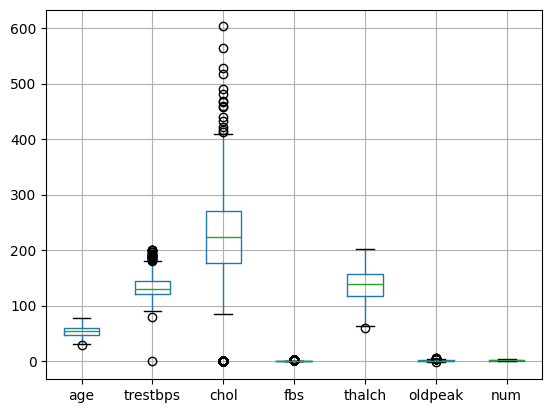

In [42]:
#Checking outliers
df.boxplot()
plt.show()

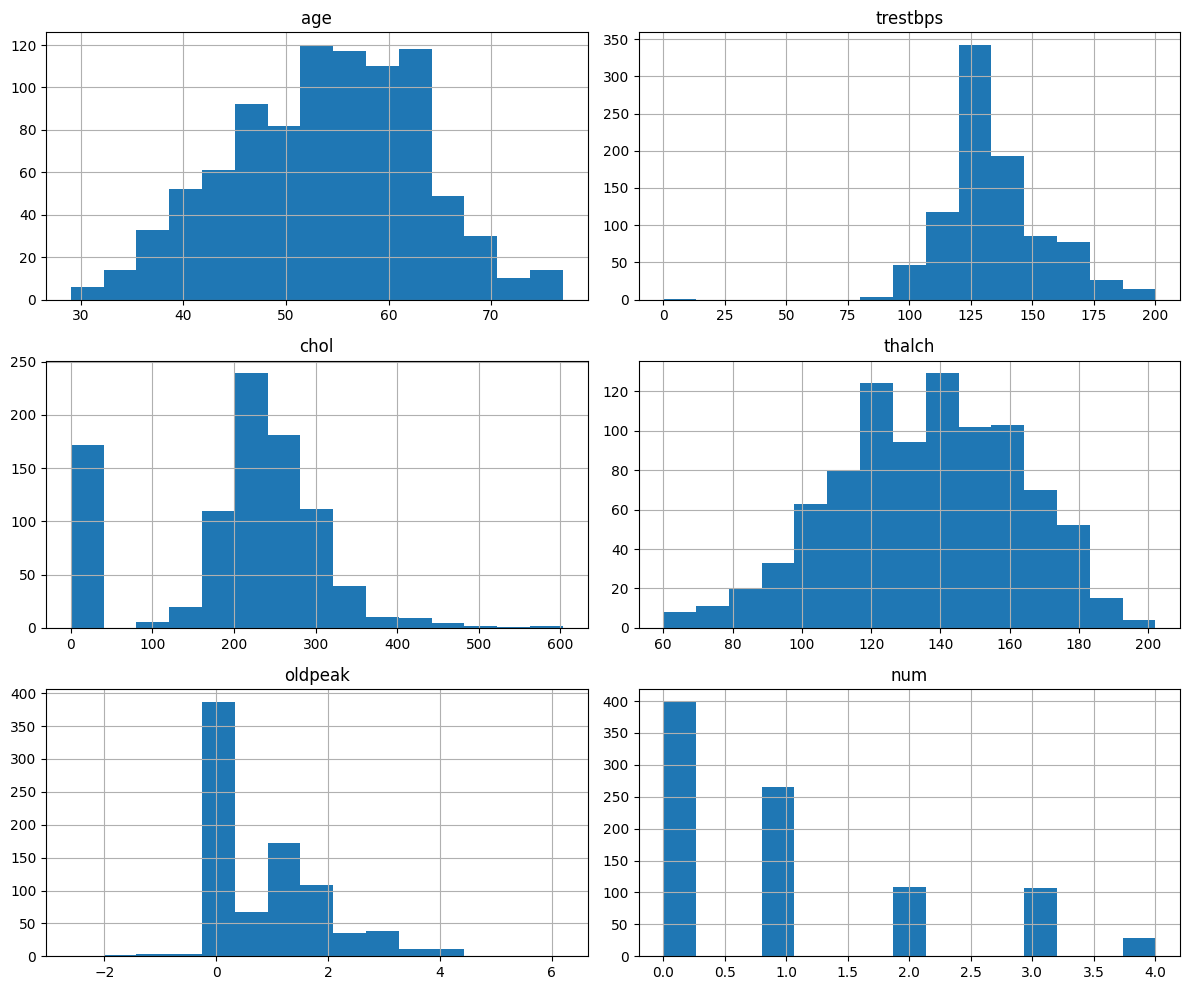

In [43]:
df.select_dtypes(include='number').hist(figsize=(12,10), bins=15)
plt.tight_layout()
plt.show()

In [83]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Create copies to avoid SettingWithCopyWarning
x = df.drop('num', axis=1).copy()
y = df['num'].copy()

# Step 1: Clean and standardize the 'exang' column
# Replace 'TURE' with True and 'FALSE' with False
x['exang'] = x['exang'].replace({'TURE': True, 'FALSE': False})

# Now convert the 'exang' column to boolean type.
# This might introduce NaNs if there are unhandled non-boolean values or actual NaNs,
# which will then be caught by the subsequent NaN handling for categorical columns.
x['exang'] = x['exang'].astype(bool)

# Impute missing values in numerical columns
# 'oldpeak' is the identified numerical column with NaNs.
# Using median is a good choice for skewed data or to be robust to outliers.
if x['oldpeak'].isnull().sum() > 0:
    x['oldpeak'] = x['oldpeak'].fillna(x['oldpeak'].median())
    print(f"NaNs in 'oldpeak' after imputation: {x['oldpeak'].isnull().sum()}")

# Identify categorical columns (now including the standardized 'exang' as boolean)
categorical_cols = x.select_dtypes(include=['object', 'bool']).columns

# Impute missing values in categorical columns with the mode
for col in categorical_cols:
    if x[col].isnull().sum() > 0:
        x[col] = x[col].fillna(x[col].mode()[0])
        print(f"NaNs in categorical column '{col}' after imputation: {x[col].isnull().sum()}")

# Verify no NaNs before one-hot encoding
initial_nan_count_x = x.isnull().sum().sum()
if initial_nan_count_x > 0:
    print(f"Warning: {initial_nan_count_x} NaNs found in 'x' before one-hot encoding. Review data preprocessing.")
else:
    print("No NaNs in 'x' before one-hot encoding.")

# Apply one-hot encoding to categorical columns
# drop_first=True helps to avoid multicollinearity
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

# Final check for any remaining NaNs in the DataFrame 'x' after one-hot encoding
final_nan_count_x = x.isnull().sum().sum()
if final_nan_count_x > 0:
    print(f"Warning: {final_nan_count_x} NaNs found in 'x' after one-hot encoding. This should not happen if previous steps were correct.")
else:
    print("No NaNs in 'x' after one-hot encoding.")

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# Final check for NaNs in the scaled array X_scaled
scaled_nan_count = np.isnan(X_scaled).sum()
if scaled_nan_count > 0:
    print(f"Error: {scaled_nan_count} NaNs found in X_scaled after scaling. This should not happen.")
else:
    print("No NaNs in X_scaled after scaling.")

# Display the first 5 rows of the scaled data
print("First 5 rows of X_scaled:")
print(X_scaled[:5])

NaNs in 'oldpeak' after imputation: 0
No NaNs in 'x' before one-hot encoding.
No NaNs in 'x' after one-hot encoding.
No NaNs in X_scaled after scaling.
First 5 rows of X_scaled:
[[ 1.00602683e+00  5.67394458e-01  2.81296736e-01  5.24183103e-01
   1.35440293e+00  5.14416131e-01 -4.71245879e-01 -5.36603450e-01
   4.37924397e+00  1.97689355e+00 -1.21691180e+00 -4.95521784e-01
  -8.34982791e-01 -9.97799777e-01 -6.98945341e-01 -7.71869208e-01
  -8.33084540e-01]
 [-1.39756029e+00  7.69668827e-02  1.35261500e-02 -1.47705269e-01
  -8.15717583e-01  5.14416131e-01  2.12203447e+00 -5.36603450e-01
  -2.28349917e-01 -5.05844131e-01  8.21752245e-01 -4.95521784e-01
  -8.34982791e-01  1.00220507e+00 -6.98945341e-01 -7.71869208e-01
  -8.33084540e-01]
 [ 3.50503068e-01  3.22180670e-01 -8.46563982e-02  4.49528839e-01
  -4.38305320e-01  5.14416131e-01 -4.71245879e-01 -5.36603450e-01
  -2.28349917e-01 -5.05844131e-01  8.21752245e-01 -4.95521784e-01
  -8.34982791e-01  1.00220507e+00 -6.98945341e-01 -7.71869

/tmp/ipykernel_972/3809861458.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['exang'] = x['exang'].replace({'TURE': True, 'FALSE': False})


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)


(726, 19)
(182, 19)


In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5384615384615384
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        80
           1       0.43      0.57      0.49        53
           2       0.17      0.09      0.12        22
           3       0.23      0.14      0.18        21
           4       0.00      0.00      0.00         6

    accuracy                           0.54       182
   macro avg       0.31      0.32      0.31       182
weighted avg       0.50      0.54      0.51       182



In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape: (726, 19)
X_test shape : (182, 19)
y_train shape: (726,)
y_test shape : (182,)


In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print('Model trained successfully')

Model trained successfully


In [52]:
y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[1 1 1 0 0 3 1 2 1 1]


In [53]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', accuracy)
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.5384615384615384

              precision    recall  f1-score   support

           0       0.73      0.79      0.76        80
           1       0.43      0.57      0.49        53
           2       0.17      0.09      0.12        22
           3       0.23      0.14      0.18        21
           4       0.00      0.00      0.00         6

    accuracy                           0.54       182
   macro avg       0.31      0.32      0.31       182
weighted avg       0.50      0.54      0.51       182



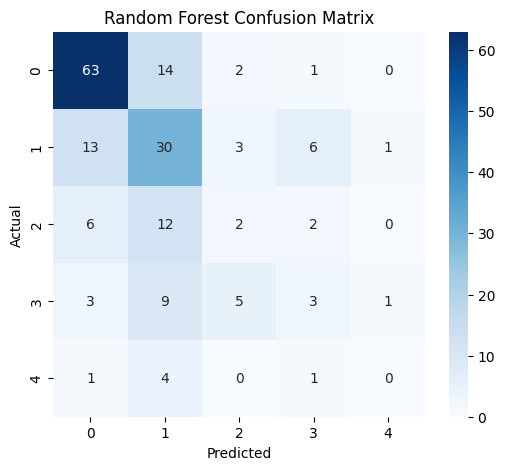

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

In [55]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag_model.fit(X_train, y_train)

bag_pred = bag_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('Bagging Accuracy:', accuracy_score(y_test, bag_pred))
print()
print(classification_report(y_test, bag_pred))

Bagging Accuracy: 0.4945054945054945

              precision    recall  f1-score   support

           0       0.72      0.75      0.74        80
           1       0.43      0.49      0.46        53
           2       0.10      0.09      0.09        22
           3       0.12      0.10      0.11        21
           4       0.00      0.00      0.00         6

    accuracy                           0.49       182
   macro avg       0.27      0.29      0.28       182
weighted avg       0.47      0.49      0.48       182



In [62]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create Bagging model
bag_model = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

# Train model
bag_model.fit(X_train, y_train)

# Predict
bag_pred = bag_model.predict(X_test)

# Evaluation
print('Bagging Accuracy:', accuracy_score(y_test, bag_pred))
print(classification_report(y_test, bag_pred))

Bagging Accuracy: 0.4945054945054945
              precision    recall  f1-score   support

           0       0.72      0.75      0.74        80
           1       0.43      0.49      0.46        53
           2       0.10      0.09      0.09        22
           3       0.12      0.10      0.11        21
           4       0.00      0.00      0.00         6

    accuracy                           0.49       182
   macro avg       0.27      0.29      0.28       182
weighted avg       0.47      0.49      0.48       182



In [76]:
#boost_model.fit(X_train, y_train)
print(X_train.shape)
print(y_train.shape)
print(X_train[:5])
# Removed print(X_train.dtypes) as X_train is a NumPy array

(726, 19)
(726,)
[[ 1.98931247  1.30303582 -1.79838815 -0.81959364  0.64830654  0.51441613
  -0.47124588  1.86357356 -0.22834992 -0.50584413 -1.2169118  -0.49552178
  -0.76823997 -0.14619278 -0.20318564  1.00220507 -0.69894534  1.29555628
  -0.83308454]
 [-0.63278257 -1.14910206  0.24559399  1.19607147  0.09947332  0.51441613
   2.12203447 -0.53660345 -0.22834992 -0.50584413  0.82175225 -0.49552178
  -0.76823997 -0.14619278 -0.20318564 -0.99779978 -0.69894534 -0.77186921
   1.20035837]
 [-1.39756029 -1.4433586  -1.79838815 -0.93157504 -0.81524872  0.51441613
  -0.47124588 -0.53660345 -0.22834992 -0.50584413 -1.2169118   2.01807475
  -0.76823997 -0.14619278 -0.20318564  1.00220507 -0.69894534 -0.77186921
   1.20035837]
 [ 1.00602683 -0.1682469   0.9507232   0.07625752  1.01419535  0.51441613
  -0.47124588 -0.53660345 -0.22834992 -0.50584413  0.82175225 -0.49552178
   1.30167662 -0.14619278 -0.20318564  1.00220507 -0.69894534 -0.77186921
   1.20035837]
 [ 0.56901099 -0.41346069  0.183114

In [79]:
# X = pd.get_dummies(X, drop_first=True) # This step is already handled in cell wqlqvhDK85BH

# from sklearn.model_selection import train_test_split # This import is already present globally or in other cells
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # This step is already handled in cell Oqwy5NWC88ls using X_scaled

In [90]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np

boost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

# Explicitly check for NaNs in X_train right before fitting
nan_count_in_X_train = np.isnan(X_train).sum()
print(f"Number of NaNs in X_train before fitting: {nan_count_in_X_train}")

if nan_count_in_X_train == 0:
    boost_model.fit(X_train, y_train)
    print('Model trained successfully')
else:
    print('Model not trained due to NaNs in X_train. Please ensure all preprocessing cells are run.')

Number of NaNs in X_train before fitting: 52
Model not trained due to NaNs in X_train. Please ensure all preprocessing cells are run.


In [98]:
print('boost_model exists:', 'boost_model' in globals())
print('X_test exists:', 'X_test' in globals())

boost_model exists: True
X_test exists: True


In [100]:
# boost_model exists: True
# X_test exists: True

In [101]:
type(X_test)

numpy.ndarray

In [103]:
print(type(boost_model))

<class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'>


In [114]:
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num']


In [115]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Features and target
X = df.drop('num', axis=1)
y = df['num']

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Fill missing values
X = X.fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# AdaBoost model
boost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

# Train
boost_model.fit(X_train, y_train)

# Predict
boost_pred = boost_model.predict(X_test)

# Results
print('Model trained successfully')
print('Predictions:', boost_pred[:10])
print('Boosting Accuracy:', accuracy_score(y_test, boost_pred))
print(classification_report(y_test, boost_pred))

Model trained successfully
Predictions: [2 1 0 1 1 2 0 0 0 1]
Boosting Accuracy: 0.5274725274725275
              precision    recall  f1-score   support

           0       0.69      0.82      0.75        89
           1       0.34      0.44      0.39        48
           2       0.17      0.05      0.07        22
           3       0.20      0.06      0.09        17
           4       0.00      0.00      0.00         6

    accuracy                           0.53       182
   macro avg       0.28      0.27      0.26       182
weighted avg       0.47      0.53      0.48       182



In [118]:
#Boosting Accuracy: 0.5274725274725275

1. Explain Bagging and Boosting methods. How are they different from each other?
Bagging (Bootstrap Aggregating)

Bagging is an ensemble learning technique in which multiple models are trained independently on different bootstrap samples of the training data. A bootstrap sample is created by randomly selecting observations with replacement. The final prediction is obtained by combining the predictions of all models, usually by majority voting for classification.
Boosting

Boosting is an ensemble technique in which models are trained sequentially. Each new model focuses more on the samples that were misclassified by the previous model. The predictions of all models are combined using weighted voting.

	Bagging	Boosting
Training process	Models trained independently	Models trained sequentially
Main objective	Reduce variance	Reduce bias
Data sampling	Bootstrap samples with replacement	Uses full data with updated sample weights
Model dependency	Independent models	Each model depends on previous model.

Conclusion:

Bagging improves stability by averaging many independent models, while Boosting improves accuracy by correcting previous errors step by step. Random Forest is a Bagging method, whereas AdaBoost is a Boosting method.

2. Explain how to handle imbalance in the data

Imbalanced data occurs when one class has significantly more samples than another class. In such cases, a model may become biased toward the majority class, and accuracy alone may be misleading.

Conclusion

Imbalanced data should be handled carefully because a model may otherwise ignore minority classes. Techniques such as stratified sampling, oversampling, undersampling, class weighting, and proper evaluation metrics help improve model performance on minority classes and produce more reliable predictions.